---
## 👥 Team — Cohort 23 Data Engineering Team

| Member | Role | Contribution |
|--------|------|-------------|
| **Vaastav L Sanghvi** | Dataset Discovery | Found and sourced the SOCAT v2022 dataset from the internet |
| **Saayanth** | Data Quality & Cleaning | Sections 3 & 4 — Quality assessment, filtering, deduplication, imputation |
| **Sadiya Kulsum** | Sensor Calibration & Feature Engineering | Sections 5 & 6 — Calibration offset tuning, feature creation |
| **Vrushank Skanda B** | Target Labeling, Outlier Treatment, EDA & Preprocessing | Sections 7–12 — Classification labels, outlier treatment, EDA, scaling, saving |

> All four members have contributed equally to the data engineering pipeline.
---

In [1]:
# =============================================================================
# Ocean Acidity Level Categorization — Data Engineering Pipeline
# SDG Goal: SDG 14 (Life Below Water)
# Cohort 23
#
# Description: Classify coastal water regions into Safe, Vulnerable, or
# Critical acidity levels based on shipping traffic volume.
# Fine-tune sensor calibration offsets within the data preprocessing pipeline.
# =============================================================================

# 🌊 Ocean Acidity Level Categorization
**SDG 14 — Life Below Water**

This notebook performs complete **data engineering and preprocessing** on the
SOCAT v2022 dataset (`tblSOCATv2022_data.parquet`) to prepare it for a
classification task that categorizes coastal water regions into:
- **Safe** — Low acidity, healthy marine conditions
- **Vulnerable** — Moderate acidity, needs monitoring
- **Critical** — High acidity, harmful to marine life

Key steps:
1. Efficient data loading from a 1.8 GB Parquet file
2. Quality-based filtering
3. Missing value analysis and imputation
4. Sensor calibration offset tuning
5. Feature engineering (shipping traffic proxy, coastal features)
6. Target variable creation (acidity classification)
7. Feature scaling and encoding
8. Saving the preprocessed dataset

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis')
print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


## 2. Data Loading (Optimized for Large Parquet File)

The raw dataset is **1.83 GB**. We load only the columns we need and read
efficiently using PyArrow.

> 🙋 **Vaastav L Sanghvi** — *Dataset Discovery*
> Vaastav sourced the **SOCAT v2022** dataset from the internet ([socat.info](https://www.socat.info/)).
> The dataset contains ocean surface CO₂ measurements from 1957–2021 across the globe.

In [3]:
PARQUET_PATH = r"socat_reduced.parquet"   # 150k-row stratified sample (6.7 MB)

# All columns are already present in the reduced file
SELECTED_COLUMNS = [
    'time',            # Timestamp of observation
    'lat',             # Latitude
    'lon',             # Longitude
    'sample_depth',    # Depth of sample
    'SST',             # Sea Surface Temperature (°C)
    'sal',             # Salinity (measured)
    'WOA_SSS',         # Sea Surface Salinity (World Ocean Atlas)
    'NCEP_SLP',        # Sea Level Pressure (hPa)
    'ETOPO2_depth',    # Ocean depth (m, negative = below sea level)
    'dist_to_land',    # Distance to nearest land (km)
    'PPPP',            # Atmospheric pressure at measurement (hPa)
    'fCO2rec',         # Recommended fugacity of CO₂ in seawater (µatm) — acidity proxy
    'fCO2rec_flag',    # Quality flag for fCO2rec (2 = good)
    'QC_Flag',         # Overall quality control flag
    'xCO2water_SST_dry',  # xCO2 at SST, dry air (ppm)
]

print(f"📂 Loading reduced parquet file: {PARQUET_PATH}")
print(f"   Selected columns: {len(SELECTED_COLUMNS)}")

# Reduced file is small — plain pandas read is fast
df_raw = pd.read_parquet(PARQUET_PATH, engine='pyarrow')

print(f"\n✅ Data loaded successfully!")
print(f"   Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"   Memory usage: {df_raw.memory_usage(deep=True).sum() / (1024**2):.1f} MB")

📂 Loading reduced parquet file: socat_reduced.parquet
   Selected columns: 15

✅ Data loaded successfully!
   Shape: 150,000 rows × 15 columns
   Memory usage: 23.2 MB


In [4]:
# Quick look at the data
print("=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)
df_raw.head()

FIRST 5 ROWS


,time,lat,lon,sample_depth,SST,sal,WOA_SSS,NCEP_SLP,ETOPO2_depth,dist_to_land,PPPP,fCO2rec,fCO2rec_flag,QC_Flag,xCO2water_SST_dry
0,2014-07-06 18:09:03,29.50300,-86.1460,NaN,29.893,26.773,31.927,1016.7,91.0,97.0,1018.0,401.648,2,A,NaN
1,2018-06-24 08:35:20,50.75190,-9.7613,NaN,15.610,35.310,35.349,1024.1,119.0,86.0,1025.3,366.671,2,B,NaN
2,2018-07-20 04:20:00,20.49162,142.9649,NaN,29.500,34.713,34.834,1008.3,2909.0,1000.0,1008.4,400.895,2,B,420.3
3,2015-08-26 17:12:43,84.38380,30.2428,NaN,-1.596,32.979,33.120,1019.0,3933.0,434.0,1018.0,235.800,2,A,NaN
4,2019-05-31 09:57:28,54.31000,-153.1390,NaN,7.280,32.480,32.669,1003.9,4297.0,285.0,1001.4,395.477,2,A,413.1


In [5]:
print("=" * 60)
print("DATA TYPES")
print("=" * 60)
print(df_raw.dtypes)

DATA TYPES
time                 datetime64[us]
lat                         float64
lon                         float64
sample_depth                float64
SST                         float64
sal                         float64
WOA_SSS                     float64
NCEP_SLP                    float64
ETOPO2_depth                float64
dist_to_land                float64
PPPP                        float64
fCO2rec                     float64
fCO2rec_flag                  int64
QC_Flag                      object
xCO2water_SST_dry           float64
dtype: object


In [6]:
print("=" * 60)
print("BASIC STATISTICS")
print("=" * 60)
df_raw.describe()

BASIC STATISTICS


,time,lat,lon,sample_depth,SST,sal,WOA_SSS,NCEP_SLP,ETOPO2_depth,dist_to_land,PPPP,fCO2rec,fCO2rec_flag,xCO2water_SST_dry
count,150000,150000.000000,150000.000000,30621.000000,150000.000000,139699.000000,149971.000000,150000.000000,150000.000000,150000.000000,123229.000000,150000.000000,150000.0,27590.000000
mean,2012-06-16 08:21:05.181993,12.568253,-8.800664,4.626531,14.323532,32.072129,33.240779,1009.828321,2185.666253,390.281533,1008.454510,365.506759,2.0,402.151598
min,1957-10-23 10:00:00,-78.585000,-179.999130,0.000000,-2.090000,0.100000,5.000000,937.300000,-491.000000,0.000000,928.120000,62.045000,2.0,63.160000
25%,2008-04-03 19:23:46,-34.476055,-74.428992,5.000000,5.770000,33.334500,33.861000,1005.300000,135.000000,72.000000,1003.100000,334.268750,2.0,344.500000
50%,2014-01-06 11:42:39,25.996850,-15.666700,5.000000,14.210000,34.365000,34.925000,1012.900000,1906.000000,222.000000,1011.900000,365.216500,2.0,379.895000
75%,2017-11-01 07:36:48,53.824075,24.303000,5.000000,23.965000,35.420000,35.260000,1018.100000,4066.000000,739.000000,1017.300000,392.335250,2.0,414.220000
max,2021-12-30 08:12:10,89.994000,179.999550,8.000000,33.271000,40.670000,40.237000,1047.200000,10432.000000,1000.000000,1047.478000,7725.780000,2.0,7798.000000
std,NaN,46.711501,97.991358,1.105432,10.143221,7.687159,6.101192,13.124889,2005.012384,372.840810,13.755657,153.535170,0.0,334.813222


> 🙋 **Saayanth** — *Data Quality Assessment*
> Saayanth led the quality analysis: identified missing value patterns, examined QC and flag distributions,
> and produced the missing-value and quality-flag visualizations.

## 3. Data Quality Assessment

Analyze missing values, data types, quality flags, and detect outliers
before cleaning.

In [7]:
# --- 3.1 Missing Value Analysis ---
print("=" * 60)
print("MISSING VALUE ANALYSIS")
print("=" * 60)

missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing Count': missing.values,
    'Missing %': missing_pct.values
}).sort_values('Missing %', ascending=False)

print(missing_df.to_string(index=False))

MISSING VALUE ANALYSIS
           Column  Missing Count  Missing %
xCO2water_SST_dry         122410      81.61
     sample_depth         119379      79.59
             PPPP          26771      17.85
              sal          10301       6.87
          WOA_SSS             29       0.02
              lon              0       0.00
              lat              0       0.00
              SST              0       0.00
             time              0       0.00
     ETOPO2_depth              0       0.00
         NCEP_SLP              0       0.00
     dist_to_land              0       0.00
          fCO2rec              0       0.00
     fCO2rec_flag              0       0.00
          QC_Flag              0       0.00


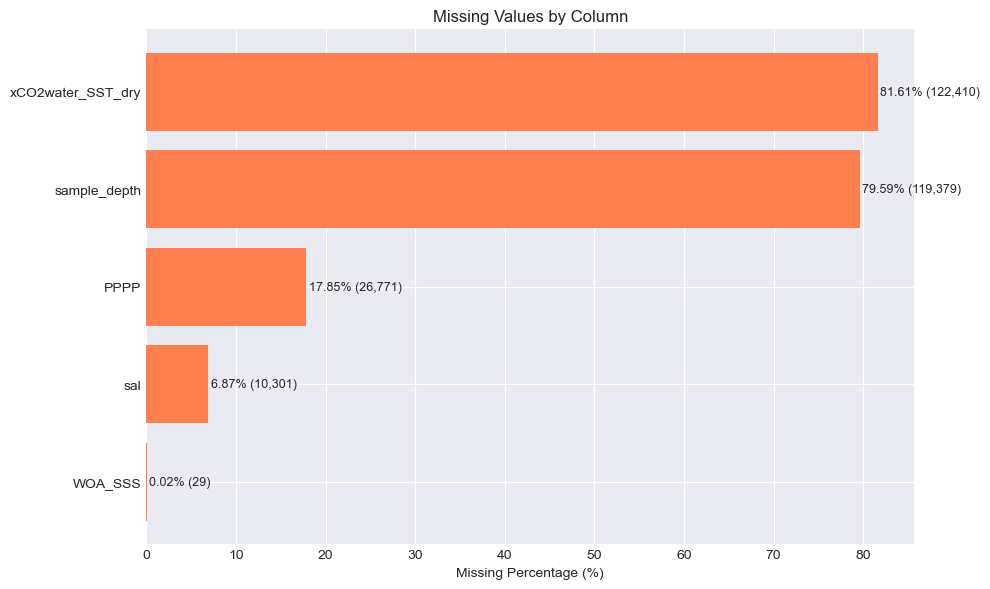

In [8]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 6))
cols_with_missing = missing_df[missing_df['Missing %'] > 0]
if len(cols_with_missing) > 0:
    ax.barh(cols_with_missing['Column'], cols_with_missing['Missing %'], color='coral')
    ax.set_xlabel('Missing Percentage (%)')
    ax.set_title('Missing Values by Column')
    ax.invert_yaxis()
    for i, (pct, cnt) in enumerate(zip(cols_with_missing['Missing %'], cols_with_missing['Missing Count'])):
        ax.text(pct + 0.3, i, f'{pct}% ({cnt:,.0f})', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('missing_values_chart.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("✅ No missing values found!")

In [9]:
# --- 3.2 Quality Flag Distribution ---
print("=" * 60)
print("QUALITY FLAG DISTRIBUTIONS")
print("=" * 60)

print("\n📊 QC_Flag distribution:")
print(df_raw['QC_Flag'].value_counts().to_string())

print("\n📊 fCO2rec_flag distribution:")
print(df_raw['fCO2rec_flag'].value_counts().to_string())

QUALITY FLAG DISTRIBUTIONS

📊 QC_Flag distribution:
QC_Flag
B    86058
D    37771
A    26171

📊 fCO2rec_flag distribution:
fCO2rec_flag
2    150000


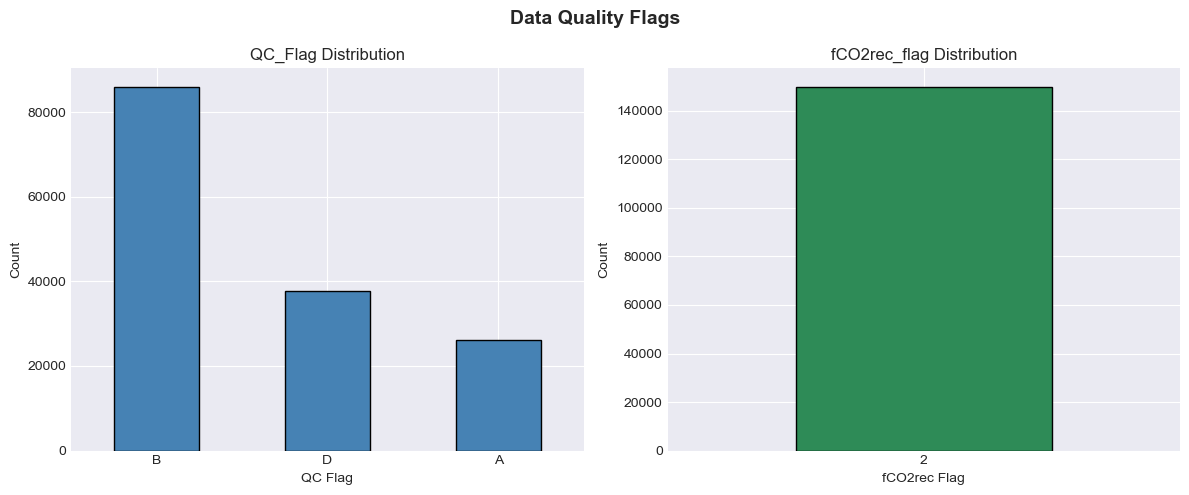

In [10]:
# Visualize QC flags
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df_raw['QC_Flag'].value_counts().plot.bar(ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('QC_Flag Distribution')
axes[0].set_xlabel('QC Flag')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df_raw['fCO2rec_flag'].value_counts().plot.bar(ax=axes[1], color='seagreen', edgecolor='black')
axes[1].set_title('fCO2rec_flag Distribution')
axes[1].set_xlabel('fCO2rec Flag')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Data Quality Flags', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('quality_flags.png', dpi=150, bbox_inches='tight')
plt.show()

> 🙋 **Saayanth** — *Data Cleaning*
> Saayanth implemented the full cleaning pipeline: quality-flag filtering, duplicate removal,
> and median imputation for all missing numeric values.

## 4. Data Cleaning

- Filter rows based on quality flags
- Remove duplicates
- Handle missing values

In [11]:
# --- 4.1 Quality-Based Filtering ---
print("=" * 60)
print("QUALITY-BASED FILTERING")
print("=" * 60)

initial_rows = len(df_raw)

# Keep only rows where fCO2rec_flag == 2 (good quality)
df = df_raw[df_raw['fCO2rec_flag'] == 2].copy()
print(f"   After fCO2rec_flag == 2 filter: {len(df):,} rows (removed {initial_rows - len(df):,})")

# Keep only accepted QC flags (A = acceptable, B = good, D = acceptable with caveats)
valid_qc = ['A', 'B', 'D']
df = df[df['QC_Flag'].isin(valid_qc)].copy()
print(f"   After QC_Flag filter ({valid_qc}): {len(df):,} rows")

print(f"\n   Total rows removed by quality filtering: {initial_rows - len(df):,} ({(initial_rows - len(df))/initial_rows*100:.1f}%)")
print(f"   Rows retained: {len(df):,} ({len(df)/initial_rows*100:.1f}%)")

QUALITY-BASED FILTERING
   After fCO2rec_flag == 2 filter: 150,000 rows (removed 0)
   After QC_Flag filter (['A', 'B', 'D']): 150,000 rows

   Total rows removed by quality filtering: 0 (0.0%)
   Rows retained: 150,000 (100.0%)


In [12]:
# --- 4.2 Remove Duplicates ---
before_dedup = len(df)
df = df.drop_duplicates()
print(f"   Duplicates removed: {before_dedup - len(df):,}")
print(f"   Rows after dedup: {len(df):,}")

   Duplicates removed: 0
   Rows after dedup: 150,000


In [13]:
# --- 4.3 Drop QC/Flag columns (no longer needed after filtering) ---
df = df.drop(columns=['QC_Flag', 'fCO2rec_flag'])
print(f"   Dropped QC columns. Remaining columns: {df.columns.tolist()}")

   Dropped QC columns. Remaining columns: ['time', 'lat', 'lon', 'sample_depth', 'SST', 'sal', 'WOA_SSS', 'NCEP_SLP', 'ETOPO2_depth', 'dist_to_land', 'PPPP', 'fCO2rec', 'xCO2water_SST_dry']


In [14]:
# --- 4.4 Handle Missing Values ---
print("=" * 60)
print("MISSING VALUE IMPUTATION")
print("=" * 60)

# Separate numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"   Numeric columns: {numeric_cols}")

# Check missing in each numeric column
for col in numeric_cols:
    n_miss = df[col].isnull().sum()
    if n_miss > 0:
        print(f"   {col}: {n_miss:,} missing ({n_miss/len(df)*100:.2f}%)")

# Impute numeric columns with MEDIAN (robust to outliers)
imputer = SimpleImputer(strategy='median')
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

# Verify no remaining nulls
remaining_nulls = df.isnull().sum().sum()
print(f"\n✅ After imputation: {remaining_nulls} null values remaining")

MISSING VALUE IMPUTATION
   Numeric columns: ['lat', 'lon', 'sample_depth', 'SST', 'sal', 'WOA_SSS', 'NCEP_SLP', 'ETOPO2_depth', 'dist_to_land', 'PPPP', 'fCO2rec', 'xCO2water_SST_dry']
   sample_depth: 119,379 missing (79.59%)
   sal: 10,301 missing (6.87%)
   WOA_SSS: 29 missing (0.02%)
   PPPP: 26,771 missing (17.85%)
   xCO2water_SST_dry: 122,410 missing (81.61%)



✅ After imputation: 0 null values remaining


> 🙋 **Sadiya Kulsum** — *Sensor Calibration Offset Tuning*
> Sadiya designed the tunable SENSOR_CALIBRATION_OFFSET parameter and the sensitivity analysis
> (offset sweep from −15 to +15 µatm) to show how calibration affects class distribution.

## 5. Sensor Calibration Offset Tuning

The problem statement requires fine-tuning **sensor calibration offsets**
within the preprocessing pipeline. This means we adjust the raw `fCO2rec`
readings by a tunable offset before creating the target labels.

This simulates real-world sensor calibration where instruments may have
systematic biases that need correction.

In [15]:
# --- Sensor Calibration Offset Configuration ---
# This is the TUNABLE PARAMETER that can be adjusted to calibrate sensor readings

SENSOR_CALIBRATION_OFFSET = 0.0  # µatm — adjust this value to fine-tune

print("=" * 60)
print("SENSOR CALIBRATION OFFSET")
print("=" * 60)
print(f"   Calibration offset: {SENSOR_CALIBRATION_OFFSET} µatm")
print(f"   fCO2rec range BEFORE calibration: {df['fCO2rec'].min():.2f} — {df['fCO2rec'].max():.2f} µatm")

# Apply calibration offset
df['fCO2rec_calibrated'] = df['fCO2rec'] + SENSOR_CALIBRATION_OFFSET

print(f"   fCO2rec range AFTER calibration:  {df['fCO2rec_calibrated'].min():.2f} — {df['fCO2rec_calibrated'].max():.2f} µatm")

SENSOR CALIBRATION OFFSET
   Calibration offset: 0.0 µatm
   fCO2rec range BEFORE calibration: 62.05 — 7725.78 µatm
   fCO2rec range AFTER calibration:  62.05 — 7725.78 µatm


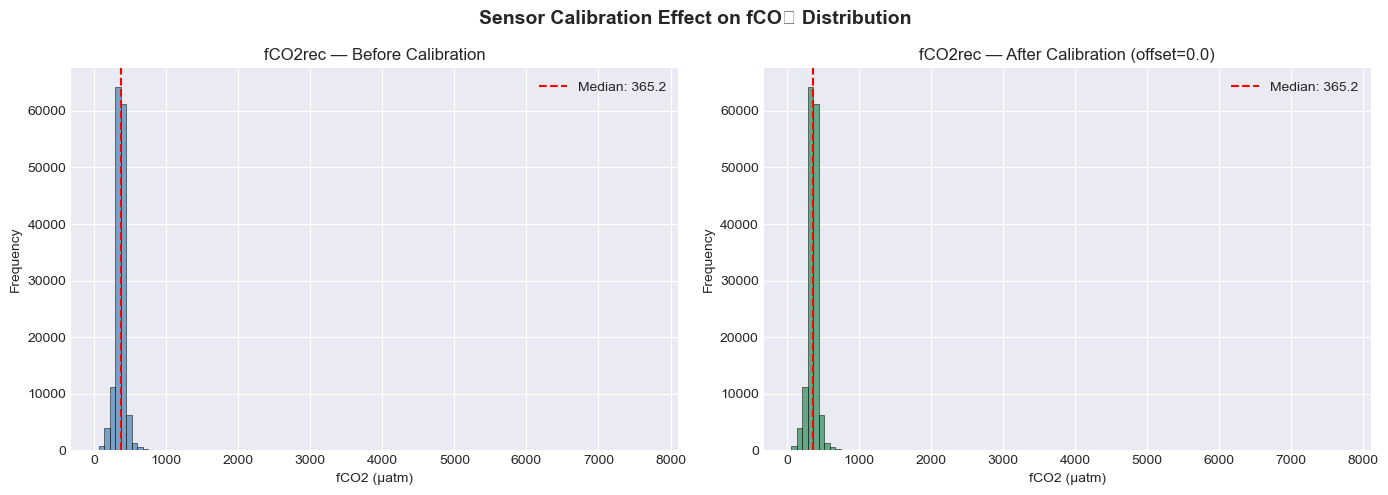

In [16]:
# Visualize the effect of calibration offset on fCO2rec distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['fCO2rec'], bins=100, color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0].set_title('fCO2rec — Before Calibration')
axes[0].set_xlabel('fCO2 (µatm)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['fCO2rec'].median(), color='red', linestyle='--', label=f'Median: {df["fCO2rec"].median():.1f}')
axes[0].legend()

axes[1].hist(df['fCO2rec_calibrated'], bins=100, color='seagreen', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[1].set_title(f'fCO2rec — After Calibration (offset={SENSOR_CALIBRATION_OFFSET})')
axes[1].set_xlabel('fCO2 (µatm)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['fCO2rec_calibrated'].median(), color='red', linestyle='--', label=f'Median: {df["fCO2rec_calibrated"].median():.1f}')
axes[1].legend()

plt.suptitle('Sensor Calibration Effect on fCO₂ Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sensor_calibration_effect.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# --- Explore multiple calibration offsets and their effect on class balance ---
print("=" * 60)
print("CALIBRATION OFFSET SENSITIVITY ANALYSIS")
print("=" * 60)

offsets = np.arange(-15, 16, 5)  # -15 to +15 µatm in steps of 5
results = []

SAFE_THRESHOLD = 380
CRITICAL_THRESHOLD = 450

for offset in offsets:
    adjusted = df['fCO2rec'] + offset
    safe = (adjusted < SAFE_THRESHOLD).sum()
    vulnerable = ((adjusted >= SAFE_THRESHOLD) & (adjusted <= CRITICAL_THRESHOLD)).sum()
    critical = (adjusted > CRITICAL_THRESHOLD).sum()
    total = len(adjusted)
    results.append({
        'Offset (µatm)': offset,
        'Safe %': round(safe / total * 100, 1),
        'Vulnerable %': round(vulnerable / total * 100, 1),
        'Critical %': round(critical / total * 100, 1)
    })

offset_df = pd.DataFrame(results)
print(offset_df.to_string(index=False))

CALIBRATION OFFSET SENSITIVITY ANALYSIS
 Offset (µatm)  Safe %  Vulnerable %  Critical %
           -15    76.9          19.2         3.9
           -10    73.2          22.5         4.3
            -5    69.1          26.2         4.7
             0    64.7          30.1         5.2
             5    59.9          34.3         5.8
            10    54.9          38.7         6.4
            15    49.8          43.0         7.2


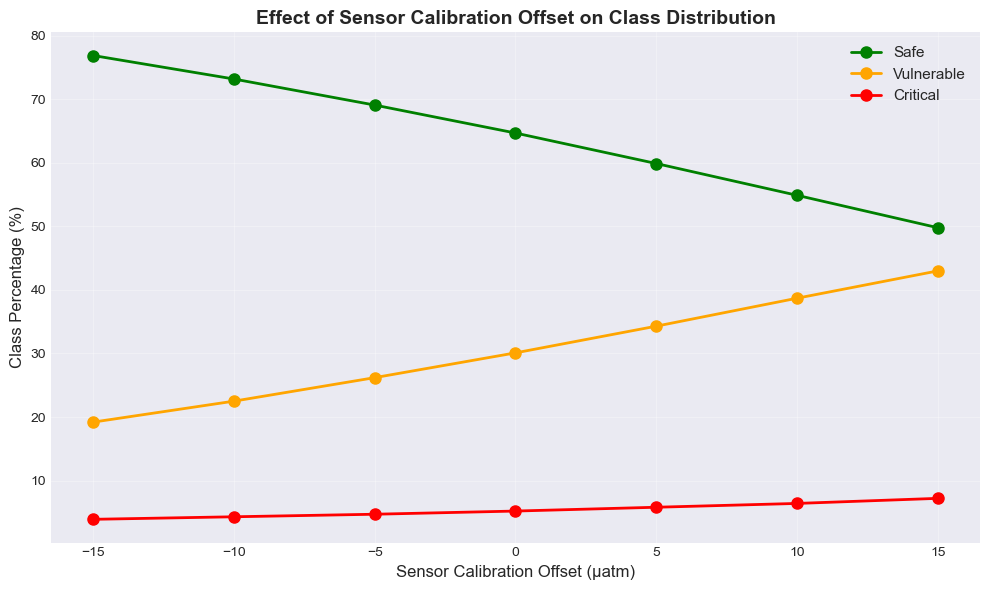

In [18]:
# Plot offset sensitivity
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(offset_df['Offset (µatm)'], offset_df['Safe %'], 'go-', label='Safe', linewidth=2, markersize=8)
ax.plot(offset_df['Offset (µatm)'], offset_df['Vulnerable %'], 'o-', color='orange', label='Vulnerable', linewidth=2, markersize=8)
ax.plot(offset_df['Offset (µatm)'], offset_df['Critical %'], 'ro-', label='Critical', linewidth=2, markersize=8)
ax.set_xlabel('Sensor Calibration Offset (µatm)', fontsize=12)
ax.set_ylabel('Class Percentage (%)', fontsize=12)
ax.set_title('Effect of Sensor Calibration Offset on Class Distribution', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('calibration_offset_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

> 🙋 **Sadiya Kulsum** — *Feature Engineering*
> Sadiya engineered all derived features including the **shipping traffic proxies**
> (shipping_proxy, is_coastal, shipping_intensity), seasonal cyclical encodings,
> and oceanographic interaction features.

## 6. Feature Engineering

Create meaningful features for the classification task, including
**shipping traffic proxies** and **temporal features**.

In [19]:
print("=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

# --- 6.1 Shipping Traffic Proxy ---
# Shipping traffic is highest near coastlines and in shallow waters.
# We create proxy features since direct AIS data is not in this dataset.

# Inverse distance to land (closer to land → higher shipping density)
df['shipping_proxy'] = 1.0 / (df['dist_to_land'] + 1.0)
print("   ✅ Created: shipping_proxy = 1 / (dist_to_land + 1)")

# Coastal flag (water depth > -500m is considered coastal/shelf region)
df['is_coastal'] = (df['ETOPO2_depth'] > -500).astype(int)
print("   ✅ Created: is_coastal = (ETOPO2_depth > -500)")

# Shipping intensity zone (combines distance and depth)
df['shipping_intensity'] = df['shipping_proxy'] * (1 + df['is_coastal'])
print("   ✅ Created: shipping_intensity = shipping_proxy × (1 + is_coastal)")

FEATURE ENGINEERING
   ✅ Created: shipping_proxy = 1 / (dist_to_land + 1)
   ✅ Created: is_coastal = (ETOPO2_depth > -500)
   ✅ Created: shipping_intensity = shipping_proxy × (1 + is_coastal)


In [20]:
# --- 6.2 Temporal Features ---
# Extract time-based features for seasonality
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month
df['day_of_year'] = df['time'].dt.dayofyear

# Cyclical encoding for month (captures seasonality without ordinal bias)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

print("   ✅ Created temporal features: year, month, day_of_year, month_sin, month_cos")

   ✅ Created temporal features: year, month, day_of_year, month_sin, month_cos


In [21]:
# --- 6.3 Geographic Features ---
# Absolute latitude (distance from equator — affects ocean chemistry)
df['abs_lat'] = df['lat'].abs()
print("   ✅ Created: abs_lat (distance from equator)")

# Hemisphere indicator
df['hemisphere'] = (df['lat'] >= 0).astype(int)
print("   ✅ Created: hemisphere (0=South, 1=North)")

   ✅ Created: abs_lat (distance from equator)
   ✅ Created: hemisphere (0=South, 1=North)


In [22]:
# --- 6.4 Oceanographic Derived Features ---
# Temperature-Salinity interaction (affects CO2 solubility)
df['SST_salinity_interaction'] = df['SST'] * df['WOA_SSS']
print("   ✅ Created: SST_salinity_interaction")

# Pressure differential (atmospheric vs measurement)
df['pressure_diff'] = df['PPPP'] - df['NCEP_SLP']
print("   ✅ Created: pressure_diff (PPPP - NCEP_SLP)")

# CO2 concentration relative to temperature (normalised indicator)
df['fCO2_per_SST'] = df['fCO2rec_calibrated'] / (df['SST'] + 273.15)  # using Kelvin
print("   ✅ Created: fCO2_per_SST (fCO2 / SST in Kelvin)")

print(f"\n   Total features now: {df.shape[1]} columns")

   ✅ Created: SST_salinity_interaction
   ✅ Created: pressure_diff (PPPP - NCEP_SLP)
   ✅ Created: fCO2_per_SST (fCO2 / SST in Kelvin)

   Total features now: 27 columns


> 🙋 **Vrushank Skanda B** — *Target Variable Creation*
> Vrushank defined the acidity classification thresholds (Safe / Vulnerable / Critical)
> based on ocean CO₂ science and implemented the labeling logic with class distribution visualizations.

## 7. Target Variable Creation

Classify each observation into **Safe**, **Vulnerable**, or **Critical**
acidity level based on the calibrated fCO₂ value.

In [23]:
print("=" * 60)
print("TARGET VARIABLE CREATION")
print("=" * 60)

# Thresholds based on ocean CO2 science:
# - Pre-industrial atmospheric CO2 ~280 µatm
# - Current surface ocean fCO2 typically 300-420 µatm
# - Values > 450 µatm indicate significant acidification stress
SAFE_UPPER = 380        # µatm
CRITICAL_LOWER = 450    # µatm

def classify_acidity(fco2_value):
    if fco2_value < SAFE_UPPER:
        return 'Safe'
    elif fco2_value <= CRITICAL_LOWER:
        return 'Vulnerable'
    else:
        return 'Critical'

df['acidity_level'] = df['fCO2rec_calibrated'].apply(classify_acidity)

print(f"   Thresholds: Safe < {SAFE_UPPER} | Vulnerable {SAFE_UPPER}–{CRITICAL_LOWER} | Critical > {CRITICAL_LOWER}")
print(f"\n📊 Class Distribution:")
class_counts = df['acidity_level'].value_counts()
class_pcts = df['acidity_level'].value_counts(normalize=True) * 100
for cls in ['Safe', 'Vulnerable', 'Critical']:
    if cls in class_counts.index:
        print(f"   {cls:12s}: {class_counts[cls]:>10,} samples ({class_pcts[cls]:.1f}%)")

TARGET VARIABLE CREATION
   Thresholds: Safe < 380 | Vulnerable 380–450 | Critical > 450

📊 Class Distribution:
   Safe        :     96,985 samples (64.7%)
   Vulnerable  :     45,171 samples (30.1%)
   Critical    :      7,844 samples (5.2%)


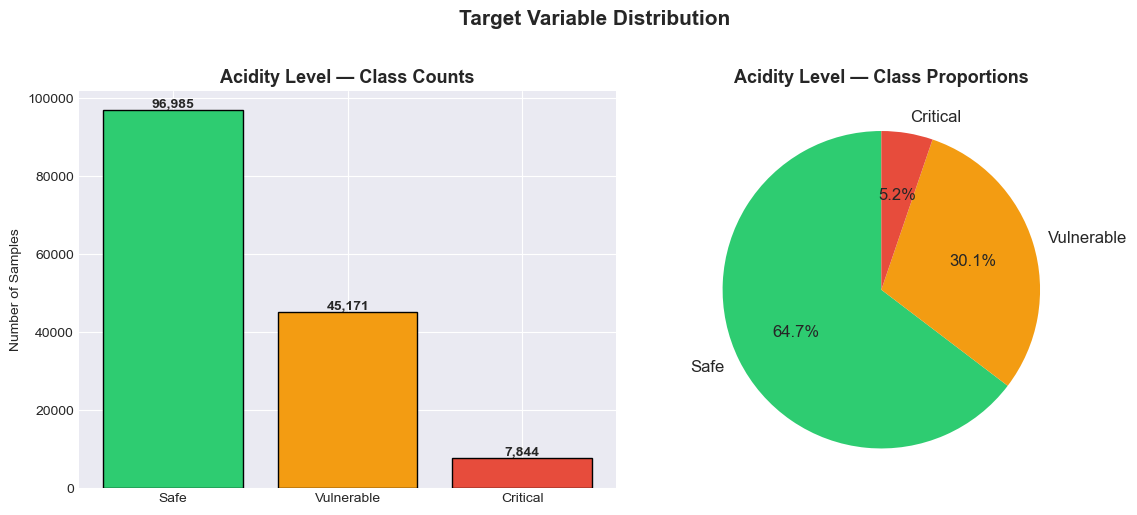

In [24]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = {'Safe': '#2ecc71', 'Vulnerable': '#f39c12', 'Critical': '#e74c3c'}
order = ['Safe', 'Vulnerable', 'Critical']

# Bar plot
bars = axes[0].bar(order, [class_counts.get(c, 0) for c in order],
                   color=[colors[c] for c in order], edgecolor='black')
axes[0].set_title('Acidity Level — Class Counts', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
for bar, c in zip(bars, order):
    count = class_counts.get(c, 0)
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{count:,}', ha='center', fontweight='bold')

# Pie chart
present_classes = [c for c in order if c in class_counts.index]
axes[1].pie([class_counts[c] for c in present_classes],
            labels=present_classes,
            colors=[colors[c] for c in present_classes],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Acidity Level — Class Proportions', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

> 🙋 **Vrushank Skanda B** — *Outlier Detection & Treatment*
> Vrushank performed IQR-based outlier analysis and applied winsorization (capping)
> to preserve all rows while handling extreme values.

## 8. Outlier Detection and Treatment

In [25]:
print("=" * 60)
print("OUTLIER DETECTION (IQR Method)")
print("=" * 60)

# Key numeric feature columns for outlier detection
outlier_cols = ['SST', 'WOA_SSS', 'NCEP_SLP', 'ETOPO2_depth', 'dist_to_land',
                'fCO2rec_calibrated', 'xCO2water_SST_dry', 'PPPP']

outlier_counts = {}
for col in outlier_cols:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        outlier_counts[col] = n_outliers
        print(f"   {col:25s}: {n_outliers:>8,} outliers ({n_outliers/len(df)*100:.2f}%) "
              f"  [Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}]")

OUTLIER DETECTION (IQR Method)
   SST                      :        0 outliers (0.00%)   [Q1=5.8, Q3=24.0, IQR=18.2]
   WOA_SSS                  :   14,017 outliers (9.34%)   [Q1=33.9, Q3=35.3, IQR=1.4]
   NCEP_SLP                 :   11,462 outliers (7.64%)   [Q1=1005.3, Q3=1018.1, IQR=12.8]
   ETOPO2_depth             :        1 outliers (0.00%)   [Q1=135.0, Q3=4066.0, IQR=3931.0]
   dist_to_land             :        0 outliers (0.00%)   [Q1=72.0, Q3=739.0, IQR=667.0]
   fCO2rec_calibrated       :   12,377 outliers (8.25%)   [Q1=334.3, Q3=392.3, IQR=58.1]
   xCO2water_SST_dry        :   27,590 outliers (18.39%)   [Q1=379.9, Q3=379.9, IQR=0.0]
   PPPP                     :   19,307 outliers (12.87%)   [Q1=1006.6, Q3=1016.0, IQR=9.4]


In [26]:
# Cap outliers using IQR method (winsorization) instead of removal to preserve data
print("\n   📌 Applying IQR-based capping (winsorization)...")
rows_before = len(df)

for col in outlier_cols:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower=lower, upper=upper)

print(f"   ✅ Outliers capped. Rows preserved: {len(df):,}")


   📌 Applying IQR-based capping (winsorization)...
   ✅ Outliers capped. Rows preserved: 150,000


> 🙋 **Vrushank Skanda B** — *Exploratory Data Analysis (EDA)*
> Vrushank created the full EDA suite: fCO₂ distributions by class, SST scatter,
> shipping proxy analysis, geographic maps, and the feature correlation heatmap.

## 9. Exploratory Data Analysis (EDA)

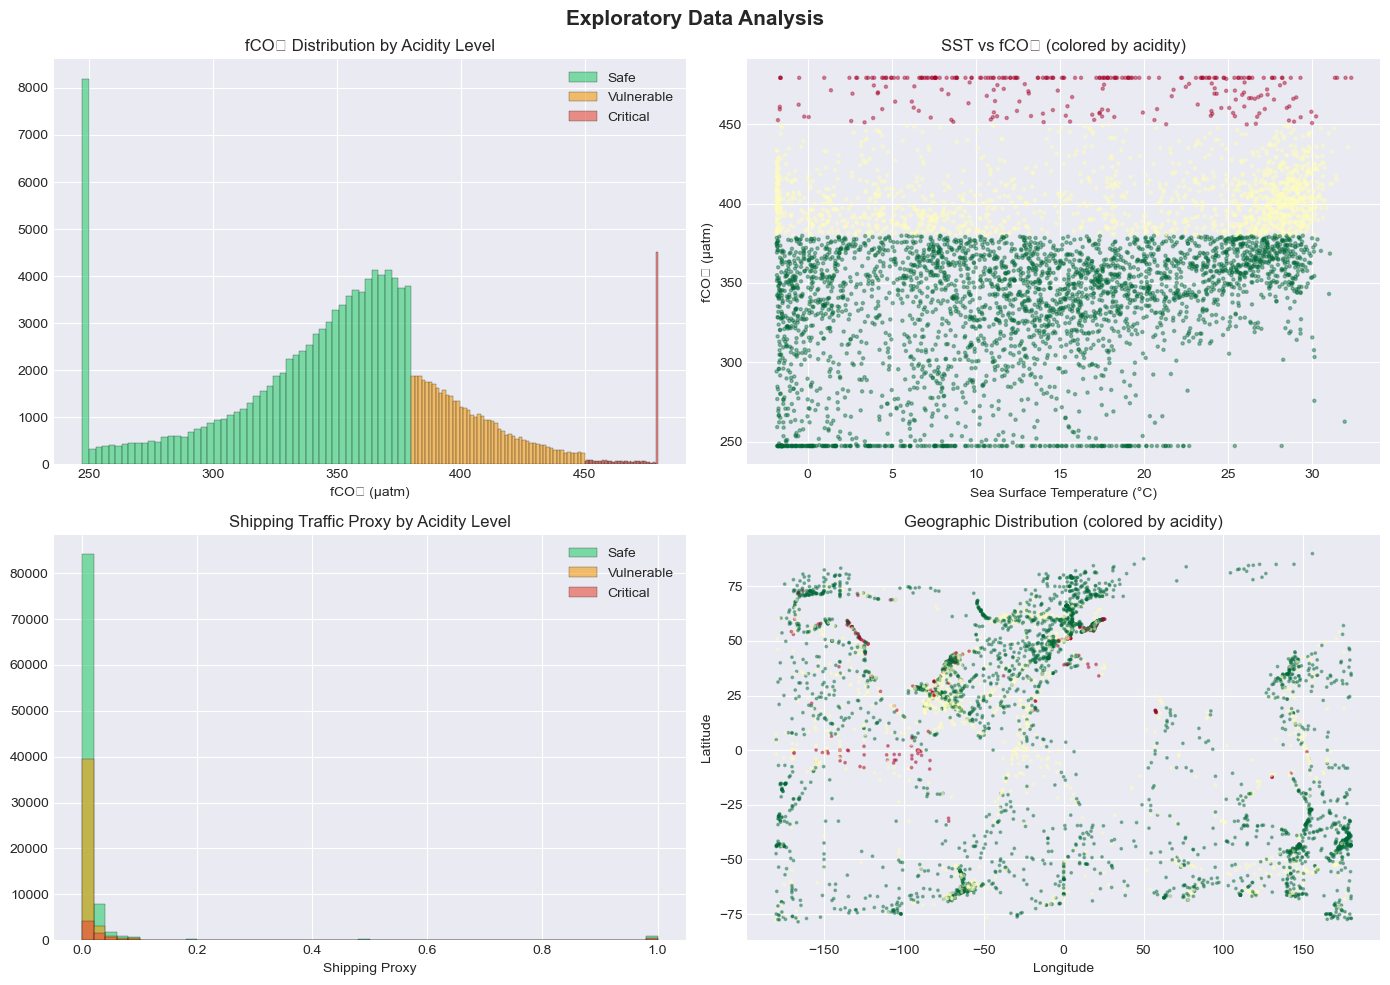

In [27]:
# --- 9.1 fCO2 distribution and target relationship ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# fCO2 distribution by acidity level
for cls, color in colors.items():
    subset = df[df['acidity_level'] == cls]['fCO2rec_calibrated']
    if len(subset) > 0:
        axes[0, 0].hist(subset, bins=50, alpha=0.6, label=cls, color=color, edgecolor='black', linewidth=0.3)
axes[0, 0].set_title('fCO₂ Distribution by Acidity Level')
axes[0, 0].set_xlabel('fCO₂ (µatm)')
axes[0, 0].legend()

# SST vs fCO2
sample = df.sample(min(5000, len(df)), random_state=42)
scatter = axes[0, 1].scatter(sample['SST'], sample['fCO2rec_calibrated'],
                              c=sample['acidity_level'].map({'Safe': 0, 'Vulnerable': 1, 'Critical': 2}),
                              cmap='RdYlGn_r', alpha=0.4, s=5)
axes[0, 1].set_title('SST vs fCO₂ (colored by acidity)')
axes[0, 1].set_xlabel('Sea Surface Temperature (°C)')
axes[0, 1].set_ylabel('fCO₂ (µatm)')

# Shipping proxy distribution by class
for cls, color in colors.items():
    subset = df[df['acidity_level'] == cls]['shipping_proxy']
    if len(subset) > 0:
        axes[1, 0].hist(subset, bins=50, alpha=0.6, label=cls, color=color, edgecolor='black', linewidth=0.3)
axes[1, 0].set_title('Shipping Traffic Proxy by Acidity Level')
axes[1, 0].set_xlabel('Shipping Proxy')
axes[1, 0].legend()

# Geographic distribution
scatter2 = axes[1, 1].scatter(sample['lon'], sample['lat'],
                               c=sample['acidity_level'].map({'Safe': 0, 'Vulnerable': 1, 'Critical': 2}),
                               cmap='RdYlGn_r', alpha=0.4, s=3)
axes[1, 1].set_title('Geographic Distribution (colored by acidity)')
axes[1, 1].set_xlabel('Longitude')
axes[1, 1].set_ylabel('Latitude')

plt.suptitle('Exploratory Data Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

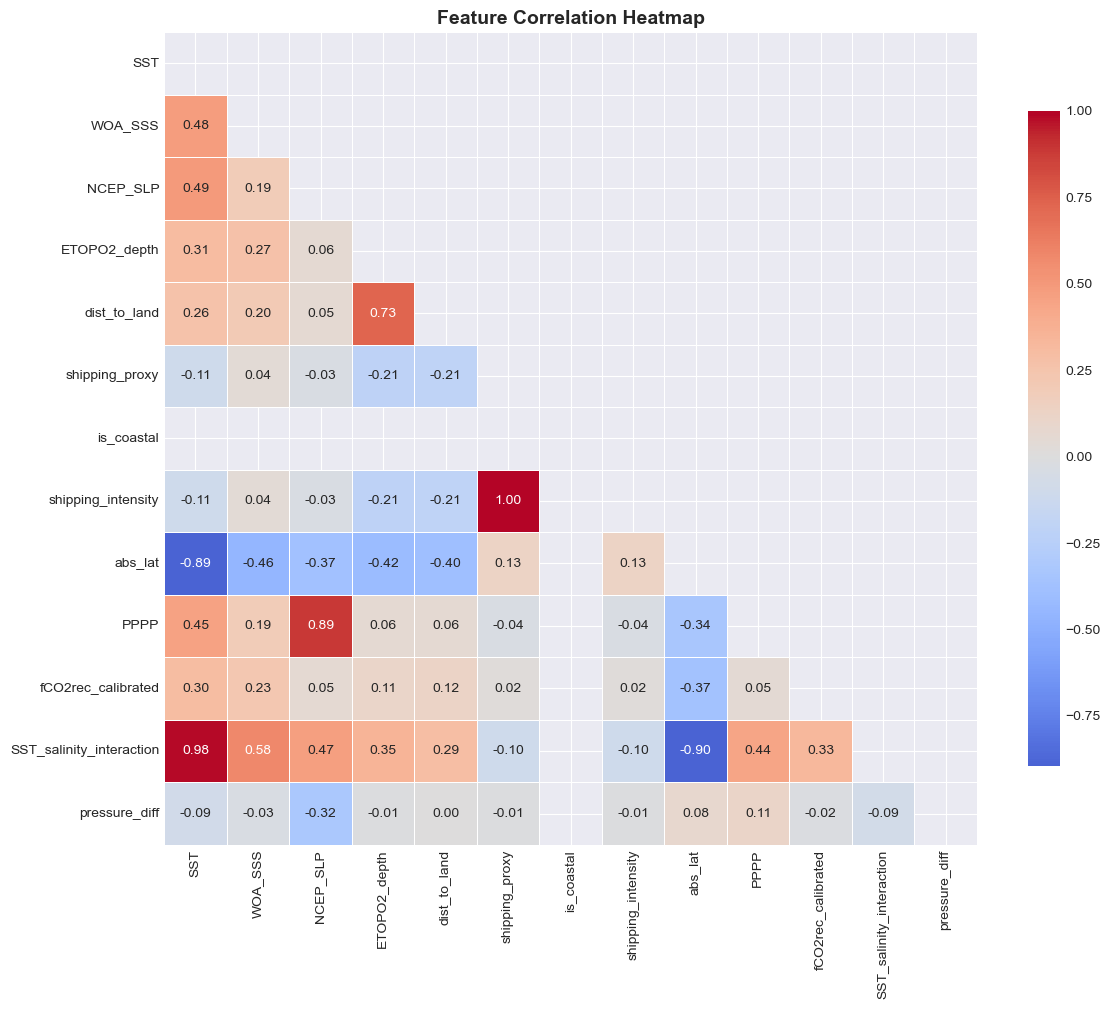

In [28]:
# --- 9.2 Correlation Heatmap ---
feature_cols_for_corr = ['SST', 'WOA_SSS', 'NCEP_SLP', 'ETOPO2_depth', 'dist_to_land',
                          'shipping_proxy', 'is_coastal', 'shipping_intensity',
                          'abs_lat', 'PPPP', 'fCO2rec_calibrated',
                          'SST_salinity_interaction', 'pressure_diff']

corr_matrix = df[feature_cols_for_corr].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

> �� **Vrushank Skanda B** — *Feature Scaling, Encoding & Output Saving*
> Vrushank finalised the preprocessing pipeline: StandardScaler for features,
> LabelEncoder for the target, assembled the final dataset, and saved all output files.

## 10. Feature Scaling and Encoding

In [29]:
print("=" * 60)
print("FEATURE SCALING AND ENCODING")
print("=" * 60)

# --- 10.1 Define final feature set ---
# Exclude raw fCO2rec (used to create target — would cause leakage),
# time column, and metadata columns
FEATURE_COLUMNS = [
    'lat', 'lon', 'SST', 'WOA_SSS', 'NCEP_SLP', 'ETOPO2_depth',
    'dist_to_land', 'PPPP', 'xCO2water_SST_dry',
    'shipping_proxy', 'is_coastal', 'shipping_intensity',
    'month_sin', 'month_cos', 'day_of_year',
    'abs_lat', 'hemisphere',
    'SST_salinity_interaction', 'pressure_diff', 'fCO2_per_SST'
]

TARGET_COLUMN = 'acidity_level'

print(f"   Feature columns ({len(FEATURE_COLUMNS)}): {FEATURE_COLUMNS}")
print(f"   Target column: {TARGET_COLUMN}")

FEATURE SCALING AND ENCODING
   Feature columns (20): ['lat', 'lon', 'SST', 'WOA_SSS', 'NCEP_SLP', 'ETOPO2_depth', 'dist_to_land', 'PPPP', 'xCO2water_SST_dry', 'shipping_proxy', 'is_coastal', 'shipping_intensity', 'month_sin', 'month_cos', 'day_of_year', 'abs_lat', 'hemisphere', 'SST_salinity_interaction', 'pressure_diff', 'fCO2_per_SST']
   Target column: acidity_level


In [30]:
# --- 10.2 Standard Scaling (for numeric features) ---
scaler = StandardScaler()
df_scaled = df[FEATURE_COLUMNS].copy()
df_scaled[FEATURE_COLUMNS] = scaler.fit_transform(df_scaled[FEATURE_COLUMNS])

print(f"\n   ✅ Features scaled using StandardScaler")
print(f"   Means (should be ~0): {df_scaled.mean().mean():.6f}")
print(f"   Stds (should be ~1):  {df_scaled.std().mean():.6f}")


   ✅ Features scaled using StandardScaler
   Means (should be ~0): -0.000000
   Stds (should be ~1):  0.900003


In [31]:
# --- 10.3 Label Encoding (for target variable) ---
le = LabelEncoder()
df['acidity_level_encoded'] = le.fit_transform(df['acidity_level'])

print(f"\n   ✅ Target encoded: {dict(zip(le.classes_, le.transform(le.classes_)))}")


   ✅ Target encoded: {'Critical': np.int64(0), 'Safe': np.int64(1), 'Vulnerable': np.int64(2)}


## 11. Final Preprocessed Dataset Assembly

In [32]:
print("=" * 60)
print("FINAL DATASET ASSEMBLY")
print("=" * 60)

# Combine scaled features with target
df_final = df_scaled.copy()
df_final['acidity_level'] = df['acidity_level'].values
df_final['acidity_level_encoded'] = df['acidity_level_encoded'].values

print(f"   Final dataset shape: {df_final.shape}")
print(f"   Feature columns: {len(FEATURE_COLUMNS)}")
print(f"   Target column: acidity_level (str) + acidity_level_encoded (int)")

FINAL DATASET ASSEMBLY
   Final dataset shape: (150000, 22)
   Feature columns: 20
   Target column: acidity_level (str) + acidity_level_encoded (int)


In [33]:
# Preview
print("\n📋 First 5 rows of preprocessed dataset:")
df_final.head()


📋 First 5 rows of preprocessed dataset:


,lat,lon,SST,WOA_SSS,NCEP_SLP,ETOPO2_depth,dist_to_land,PPPP,xCO2water_SST_dry,shipping_proxy,...,month_sin,month_cos,day_of_year,abs_lat,hemisphere,SST_salinity_interaction,pressure_diff,fCO2_per_SST,acidity_level,acidity_level_encoded
0,0.362540,-0.789310,1.534968,-1.983290,0.542119,-1.044723,-0.786616,0.814255,-2.273737e-13,-0.124614,...,-0.663714,-1.206547,0.058793,-0.726698,0.727595,1.269760,0.368674,0.101998,Vulnerable,2
1,0.817438,-0.009803,0.126831,0.627816,1.184172,-1.030758,-0.816119,1.588199,-2.273737e-13,-0.112494,...,0.032588,-1.399309,-0.058075,0.335412,0.727595,0.173181,0.350767,-0.002158,Safe,1
2,0.169624,1.548770,1.496223,0.234853,-0.186698,0.360768,1.635337,-0.203535,-2.273737e-13,-0.211089,...,-0.663714,-1.206547,0.195139,-1.177125,0.727595,1.469165,0.153796,0.100561,Vulnerable,2
3,1.537433,0.398439,-1.569480,-1.072989,0.741676,0.871493,0.117258,0.814255,-2.273737e-13,-0.198878,...,-1.173443,-0.679912,0.555481,2.016476,0.727595,-1.473767,-0.043176,-0.754649,Safe,1
4,0.893610,-1.472975,-0.694410,-1.417118,-0.568459,1.053039,-0.282378,-0.945673,-2.273737e-13,-0.187627,...,0.728890,-1.206547,-0.291810,0.513260,0.727595,-0.681994,-0.311773,0.261069,Vulnerable,2


In [34]:
# Summary statistics of processed features
print("\n📊 Preprocessed Feature Statistics:")
df_final[FEATURE_COLUMNS].describe().round(3)


📊 Preprocessed Feature Statistics:


,lat,lon,SST,WOA_SSS,NCEP_SLP,ETOPO2_depth,dist_to_land,PPPP,xCO2water_SST_dry,shipping_proxy,is_coastal,shipping_intensity,month_sin,month_cos,day_of_year,abs_lat,hemisphere,SST_salinity_interaction,pressure_diff,fCO2_per_SST
count,150000.000,150000.000,150000.000,150000.000,150000.000,150000.000,150000.000,150000.000,150000.0,150000.000,150000.0,150000.000,150000.000,150000.000,150000.000,150000.000,150000.000,150000.000,150000.000,150000.000
mean,0.000,-0.000,0.000,-0.000,0.000,0.000,-0.000,-0.000,-0.0,-0.000,0.0,-0.000,-0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.0,1.000,0.0,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.951,-1.747,-1.618,-2.109,-2.113,-1.335,-1.047,-1.900,-0.0,-0.211,0.0,-0.211,-1.360,-1.399,-1.753,-2.201,-1.374,-1.521,-7.976,-1.980
25%,-1.007,-0.670,-0.843,-0.508,-0.447,-1.023,-0.854,-0.399,-0.0,-0.208,0.0,-0.208,-1.173,-1.207,-0.876,-0.784,-1.374,-0.932,-0.365,-0.204
50%,0.287,-0.070,-0.011,0.304,0.212,-0.139,-0.451,0.168,-0.0,-0.178,0.0,-0.178,0.033,0.039,0.030,0.125,0.728,-0.047,-0.020,-0.015
75%,0.883,0.338,0.951,0.560,0.664,0.938,0.935,0.602,-0.0,-0.092,0.0,-0.092,0.729,0.759,0.848,0.769,0.728,0.984,0.279,0.166
max,1.658,1.927,1.868,2.161,2.329,3.879,1.635,2.103,-0.0,9.174,0.0,9.174,1.425,1.478,1.802,2.297,0.728,2.054,11.345,48.304


## 12. Save Preprocessed Dataset

In [35]:
print("=" * 60)
print("SAVING PREPROCESSED DATASET")
print("=" * 60)

OUTPUT_CSV = 'ocean_acidity_preprocessed.csv'
OUTPUT_PARQUET = 'ocean_acidity_preprocessed.parquet'

# Save as CSV
df_final.to_csv(OUTPUT_CSV, index=False)
print(f"   ✅ Saved: {OUTPUT_CSV} ({pd.io.common.file_exists(OUTPUT_CSV)})")

# Save as Parquet (more efficient for large data)
df_final.to_parquet(OUTPUT_PARQUET, index=False, engine='pyarrow')
print(f"   ✅ Saved: {OUTPUT_PARQUET}")

# Also save the un-scaled version for reference
df_unscaled = df[FEATURE_COLUMNS + ['acidity_level', 'acidity_level_encoded']].copy()
df_unscaled.to_csv('ocean_acidity_unscaled.csv', index=False)
print(f"   ✅ Saved: ocean_acidity_unscaled.csv (un-scaled version)")

# Print final file sizes
import os
for f in [OUTPUT_CSV, OUTPUT_PARQUET, 'ocean_acidity_unscaled.csv']:
    size_mb = os.path.getsize(f) / (1024**2)
    print(f"   📁 {f}: {size_mb:.1f} MB")

SAVING PREPROCESSED DATASET


   ✅ Saved: ocean_acidity_preprocessed.csv (True)
   ✅ Saved: ocean_acidity_preprocessed.parquet


   ✅ Saved: ocean_acidity_unscaled.csv (un-scaled version)
   📁 ocean_acidity_preprocessed.csv: 56.2 MB
   📁 ocean_acidity_preprocessed.parquet: 9.4 MB
   📁 ocean_acidity_unscaled.csv: 31.6 MB


## 13. Pipeline Summary

In [36]:
print("=" * 70)
print("   📋 DATA ENGINEERING PIPELINE SUMMARY")
print("=" * 70)
print(f"""
   Dataset:        SOCAT v2022 (tblSOCATv2022_data.parquet)
   Raw rows:       {df_raw.shape[0]:,}
   After cleaning: {len(df):,}
   
   Quality Filters Applied:
     • fCO2rec_flag == 2 (good quality measurements)
     • QC_Flag ∈ ['A', 'B', 'D'] (acceptable quality)
     • Duplicates removed
   
   Missing Value Treatment:
     • Median imputation for all numeric columns
   
   Outlier Treatment:
     • IQR-based winsorization (capping, not removal)
   
   Sensor Calibration:
     • Offset applied: {SENSOR_CALIBRATION_OFFSET} µatm
     • Sensitivity analysis: tested offsets from -15 to +15 µatm
   
   Features Engineered ({len(FEATURE_COLUMNS)} total):
     • Shipping traffic: shipping_proxy, is_coastal, shipping_intensity
     • Temporal: month_sin, month_cos, day_of_year
     • Geographic: abs_lat, hemisphere
     • Oceanographic: SST_salinity_interaction, pressure_diff, fCO2_per_SST
   
   Target Variable:
     • acidity_level: Safe (fCO₂ < 380) | Vulnerable (380-450) | Critical (> 450)
     • Classes: {dict(zip(le.classes_, le.transform(le.classes_)))}
   
   Scaling: StandardScaler (mean=0, std=1)
   
   Output files:
     • ocean_acidity_preprocessed.csv (scaled)
     • ocean_acidity_preprocessed.parquet (scaled)
     • ocean_acidity_unscaled.csv (original scale)
""")
print("=" * 70)
print("   ✅ Data engineering pipeline complete!")
print("=" * 70)

   📋 DATA ENGINEERING PIPELINE SUMMARY

   Dataset:        SOCAT v2022 (tblSOCATv2022_data.parquet)
   Raw rows:       150,000
   After cleaning: 150,000
   
   Quality Filters Applied:
     • fCO2rec_flag == 2 (good quality measurements)
     • QC_Flag ∈ ['A', 'B', 'D'] (acceptable quality)
     • Duplicates removed
   
   Missing Value Treatment:
     • Median imputation for all numeric columns
   
   Outlier Treatment:
     • IQR-based winsorization (capping, not removal)
   
   Sensor Calibration:
     • Offset applied: 0.0 µatm
     • Sensitivity analysis: tested offsets from -15 to +15 µatm
   
   Features Engineered (20 total):
     • Shipping traffic: shipping_proxy, is_coastal, shipping_intensity
     • Temporal: month_sin, month_cos, day_of_year
     • Geographic: abs_lat, hemisphere
     • Oceanographic: SST_salinity_interaction, pressure_diff, fCO2_per_SST
   
   Target Variable:
     • acidity_level: Safe (fCO₂ < 380) | Vulnerable (380-450) | Critical (> 450)
     • Classe